In [1]:
pip install transformers torch torchvision pillow scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import torch
from PIL import Image
from transformers import ViTImageProcessor, ViTModel
from sklearn.metrics.pairwise import cosine_similarity
import os

In [3]:
model_name = "google/vit-base-patch16-224"

processor = ViTImageProcessor.from_pretrained(model_name)
model = ViTModel.from_pretrained(model_name)

model.eval()
# Load pretrained ViT model

Some weights of ViTModel were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


ViTModel(
  (embeddings): ViTEmbeddings(
    (patch_embeddings): ViTPatchEmbeddings(
      (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    )
    (dropout): Dropout(p=0.0, inplace=False)
  )
  (encoder): ViTEncoder(
    (layer): ModuleList(
      (0-11): 12 x ViTLayer(
        (attention): ViTAttention(
          (attention): ViTSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
          )
          (output): ViTSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.0, inplace=False)
          )
        )
        (intermediate): ViTIntermediate(
          (dense): Linear(in_features=768, out_features=3072, bias=True)
          (intermediate_act_fn): GELUActivation()
        )
        (output): ViTOutput(
          (d

In [4]:
def extract_features(image_path):
    image = Image.open(image_path).convert("RGB")

    inputs = processor(images=image, return_tensors="pt")

    with torch.no_grad():
        outputs = model(**inputs)

    # Use CLS token as image feature
    features = outputs.last_hidden_state[:, 0, :]

    return features.numpy()
# Function to extract image features

In [5]:
image_folder = "images"

stored_images = [
    os.path.join(image_folder, "cat1.jpeg"),
    os.path.join(image_folder, "cat2.jpeg"),
    os.path.join(image_folder, "cat3.jpeg"),
    os.path.join(image_folder, "cat4.jpeg"),
    os.path.join(image_folder, "cat5.jpeg")
]

stored_features = []

for image_path in stored_images:
    feature = extract_features(image_path)
    stored_features.append(feature)

print("Features extracted successfully!")
# known images

Features extracted successfully!


In [6]:
test_image = "cat.jpeg"

test_feature = extract_features(test_image)
# Giving new image

In [7]:
similarities = []

for feature in stored_features:
    score = cosine_similarity(test_feature, feature)[0][0]
    similarities.append(score)

print("Similarity Scores:")
for image, score in zip(stored_images, similarities):
    print(image, ":", round(score, 4))

Similarity Scores:
images\cat1.jpeg : 0.7328
images\cat2.jpeg : 0.7586
images\cat3.jpeg : 0.6436
images\cat4.jpeg : 0.6167
images\cat5.jpeg : 0.7593


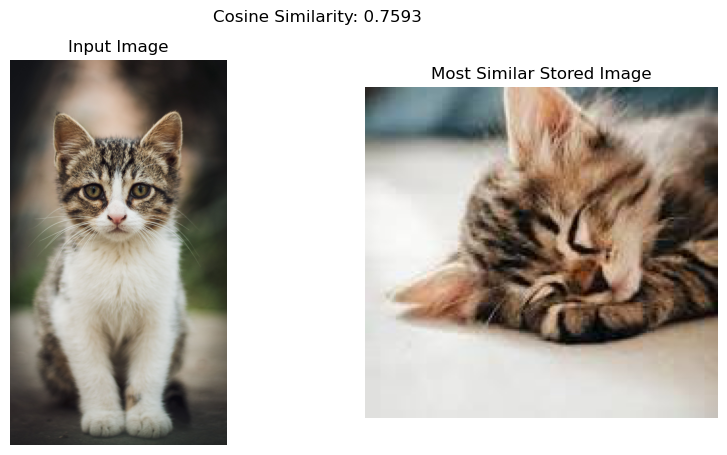

In [8]:
import matplotlib.pyplot as plt

best_index = similarities.index(max(similarities))
most_similar_image = stored_images[best_index]
best_score = similarities[best_index]

# Display images
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(Image.open(test_image).convert("RGB"))
plt.title("Input Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(Image.open(most_similar_image).convert("RGB"))
plt.title("Most Similar Stored Image")
plt.axis("off")

plt.suptitle(f"Cosine Similarity: {best_score:.4f}")
plt.show()

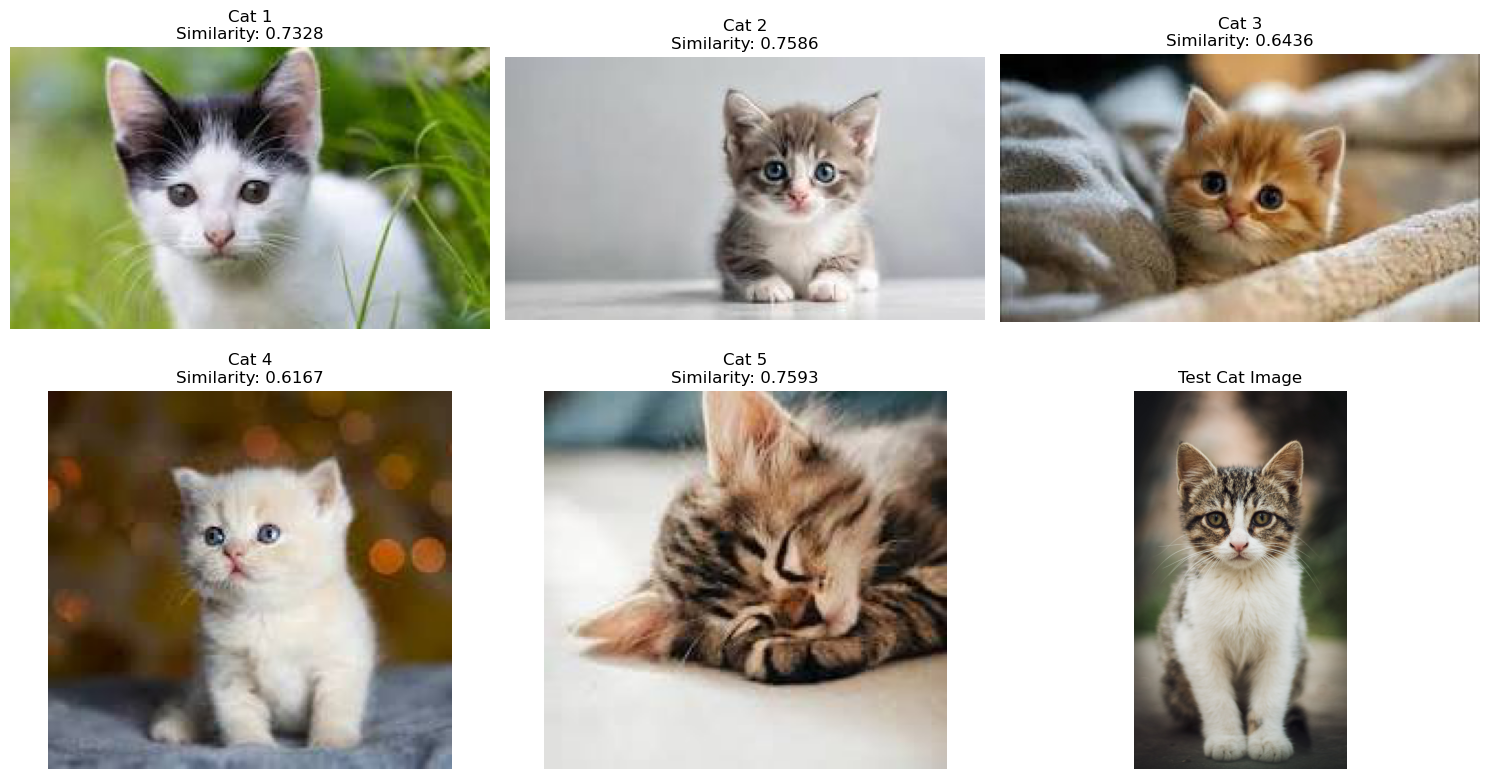

In [9]:
plt.figure(figsize=(15, 8))

for i, (image_path, score) in enumerate(zip(stored_images, similarities)):
    plt.subplot(2, 3, i + 1)
    
    image = Image.open(image_path).convert("RGB")
    plt.imshow(image)
    
    plt.title(f"Cat {i+1}\nSimilarity: {score:.4f}")
    plt.axis("off")

# Display test image also
plt.subplot(2, 3, 6)
plt.imshow(Image.open(test_image).convert("RGB"))
plt.title("Test Cat Image")
plt.axis("off")

plt.tight_layout()
plt.show()